## Problem Statement: Mobile Phone Price Range Prediction

**Goal:** Develop a machine learning model to predict the **price range** of a mobile phone based on its various specifications and features.

**Dataset:** The provided dataset contains various attributes of mobile phones, including battery power, camera specifications, screen dimensions, RAM, internal memory, and network capabilities.

**Task:** The primary task is to build a **classification model** that can categorize a mobile phone into a predefined price range (e.g., low-end, mid-range, high-end) given its technical specifications. Since the current dataset does not have an explicit 'price range' column, we will first need to create one. For this problem, we will assume a hypothetical 'price_range' target variable that needs to be generated based on existing numerical features like RAM, battery_power, px_height, and px_width.

**Steps involved will include:**
1. **EDA** : Explore distributions of some of the major columns like battery power, 4g, clock speed.
2.  **Feature Engineering:** Create a target variable, 'price_range', from existing features.
3.  **Data Preprocessing:** Prepare the data for model training (e.g., scaling, handling categorical features if any were present).
4.  **Model Selection:** Choose appropriate classification algorithms.
5.  **Model Training:** Train the selected model(s) on the preprocessed data.
6.  **Model Evaluation:** Assess the performance of the model using relevant metrics (e.g., accuracy, precision, recall, F1-score).

This predictive model could be useful for manufacturers to understand how different specifications influence the market positioning of their products, or for consumers to get an estimate of a phone's price range based on its features.

In [1]:
from google.colab import files
files.upload()

Saving test.csv to test.csv


{'test.csv': b'id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi\r\n1,1043,1,1.8,1,14,0,5,0.1,193,3,16,226,1412,3476,12,7,2,0,1,0\r\n2,841,1,0.5,1,4,1,61,0.8,191,5,12,746,857,3895,6,0,7,1,0,0\r\n3,1807,1,2.8,0,1,0,27,0.9,186,3,4,1270,1366,2396,17,10,10,0,1,1\r\n4,1546,0,0.5,1,18,1,25,0.5,96,8,20,295,1752,3893,10,0,7,1,1,0\r\n5,1434,0,1.4,0,11,1,49,0.5,108,6,18,749,810,1773,15,8,7,1,0,1\r\n6,1464,1,2.9,1,5,1,50,0.8,198,8,9,569,939,3506,10,7,3,1,1,1\r\n7,1718,0,2.4,0,1,0,47,1,156,2,3,1283,1374,3873,14,2,10,0,0,0\r\n8,833,0,2.4,1,0,0,62,0.8,111,1,2,1312,1880,1495,7,2,18,0,1,1\r\n9,1111,1,2.9,1,9,1,25,0.6,101,5,19,556,876,3485,11,9,10,1,1,0\r\n10,1520,0,0.5,0,1,0,25,0.5,171,3,20,52,1009,651,6,0,5,1,0,1\r\n11,1500,0,2.2,0,2,0,55,0.6,80,7,6,503,1336,3866,13,7,20,0,1,0\r\n12,1343,0,2.9,0,2,1,34,0.8,171,3,6,235,1671,3911,15,8,8,1,1,1\r\n13,900,1,1.4,1,0,0,30,1,87,2,3,829,1893,439,6,2,2

In [ ]:
# Rename the uploaded file
!mv test.csv mobile.csv

# Verify the file has been renamed
!ls

In [2]:
import pandas as pd

df = pd.read_csv('mobile.csv')

In [11]:
df.head()

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             1000 non-null   int64  
 1   battery_power  1000 non-null   int64  
 2   blue           1000 non-null   int64  
 3   clock_speed    1000 non-null   float64
 4   dual_sim       1000 non-null   int64  
 5   fc             1000 non-null   int64  
 6   four_g         1000 non-null   int64  
 7   int_memory     1000 non-null   int64  
 8   m_dep          1000 non-null   float64
 9   mobile_wt      1000 non-null   int64  
 10  n_cores        1000 non-null   int64  
 11  pc             1000 non-null   int64  
 12  px_height      1000 non-null   int64  
 13  px_width       1000 non-null   int64  
 14  ram            1000 non-null   int64  
 15  sc_h           1000 non-null   int64  
 16  sc_w           1000 non-null   int64  
 17  talk_time      1000 non-null   int64  
 18  three_g  

In [45]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,1248.510000,0.516000,1.540900,0.517000,4.593000,0.487000,33.652000,0.517500,139.51100,...,10.054000,627.121000,1239.774000,2138.998000,11.995000,5.316000,11.085000,0.756000,0.50000,0.507000
std,288.819436,432.458227,0.499994,0.829268,0.499961,4.463325,0.500081,18.128694,0.280861,34.85155,...,6.095099,432.929699,439.670981,1088.092278,4.320607,4.240062,5.497636,0.429708,0.50025,0.500201
min,1.000000,500.000000,0.000000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.00000,...,0.000000,0.000000,501.000000,263.000000,5.000000,0.000000,2.000000,0.000000,0.00000,0.000000
25%,250.750000,895.000000,0.000000,0.700000,0.000000,1.000000,0.000000,18.000000,0.300000,109.75000,...,5.000000,263.750000,831.750000,1237.250000,8.000000,2.000000,6.750000,1.000000,0.00000,0.000000
50%,500.500000,1246.500000,1.000000,1.500000,1.000000,3.000000,0.000000,34.500000,0.500000,139.00000,...,10.000000,564.500000,1250.000000,2153.500000,12.000000,5.000000,11.000000,1.000000,0.50000,1.000000
75%,750.250000,1629.250000,1.000000,2.300000,1.000000,7.000000,1.000000,49.000000,0.800000,170.00000,...,16.000000,903.000000,1637.750000,3065.500000,16.000000,8.000000,16.000000,1.000000,1.00000,1.000000
max,1000.000000,1999.000000,1.000000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.00000,...,20.000000,1907.000000,1998.000000,3989.000000,19.000000,18.000000,20.000000,1.000000,1.00000,1.000000


In [7]:
df.mean()

,0
id,500.5000
battery_power,1248.5100
blue,0.5160
clock_speed,1.5409
dual_sim,0.5170
fc,4.5930
four_g,0.4870
int_memory,33.6520
m_dep,0.5175
mobile_wt,139.5110


In [3]:
df.var()

,0
id,8.341667e+04
battery_power,1.870201e+05
blue,2.499940e-01
clock_speed,6.876849e-01
dual_sim,2.499610e-01
fc,1.992127e+01
four_g,2.500811e-01
int_memory,3.286495e+02
m_dep,7.888263e-02
mobile_wt,1.214631e+03


In [9]:
df.std()

,0
id,288.819436
battery_power,432.458227
blue,0.499994
clock_speed,0.829268
dual_sim,0.499961
fc,4.463325
four_g,0.500081
int_memory,18.128694
m_dep,0.280861
mobile_wt,34.851550


The **standard deviation** is a measure of the amount of variation or dispersion of a set of values. A low standard deviation indicates that the values tend to be close to the mean (also called the expected value) of the set, while a high standard deviation indicates that the values are spread out over a wider range.

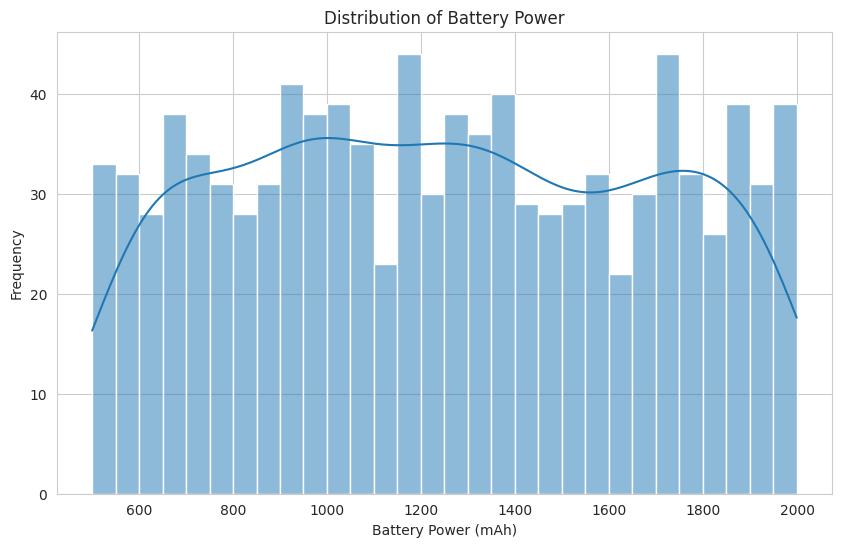

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots for better aesthetics
sns.set_style("whitegrid")

# Create a histogram for 'battery_power'
plt.figure(figsize=(10, 6))
sns.histplot(df['battery_power'], kde=True, bins=30)
plt.title('Distribution of Battery Power')
plt.xlabel('Battery Power (mAh)')
plt.ylabel('Frequency')
plt.show()

This histogram shows the distribution of 'battery_power' in your dataset. The x-axis represents the battery power in mAh, and the y-axis shows how many phones fall into each battery power range (frequency). The curve overlaid on the histogram is a Kernel Density Estimate (KDE), which smooths out the histogram to show the underlying distribution shape.

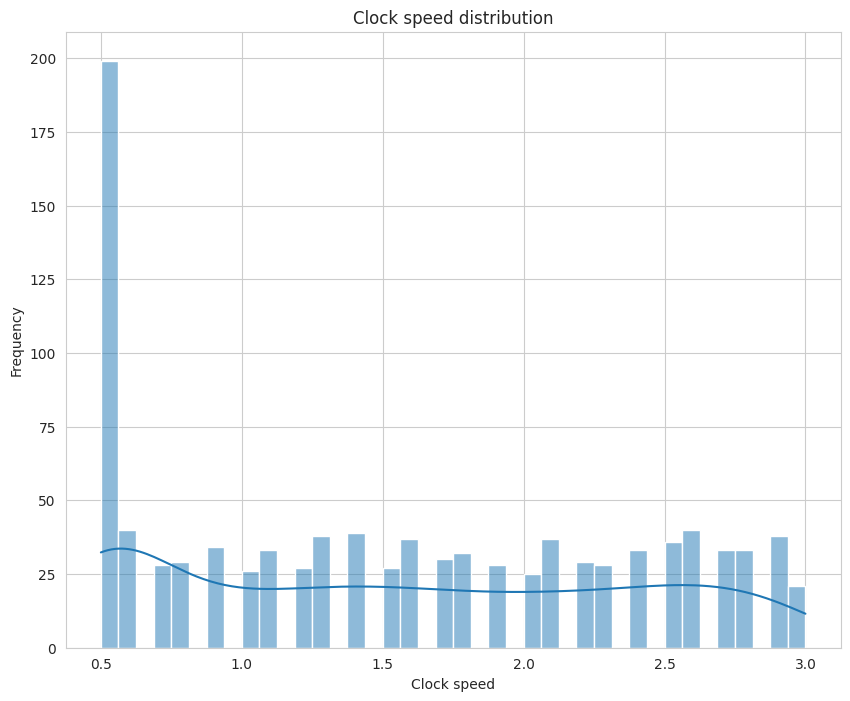

In [ ]:
sns.set_style('whitegrid')

plt.figure(figsize = (10,8))
sns.histplot(df['clock_speed'], kde = True, bins = 40)
plt.title('Clock speed distribution')
plt.xlabel('Clock speed')
plt.ylabel('Frequency')
plt.show()

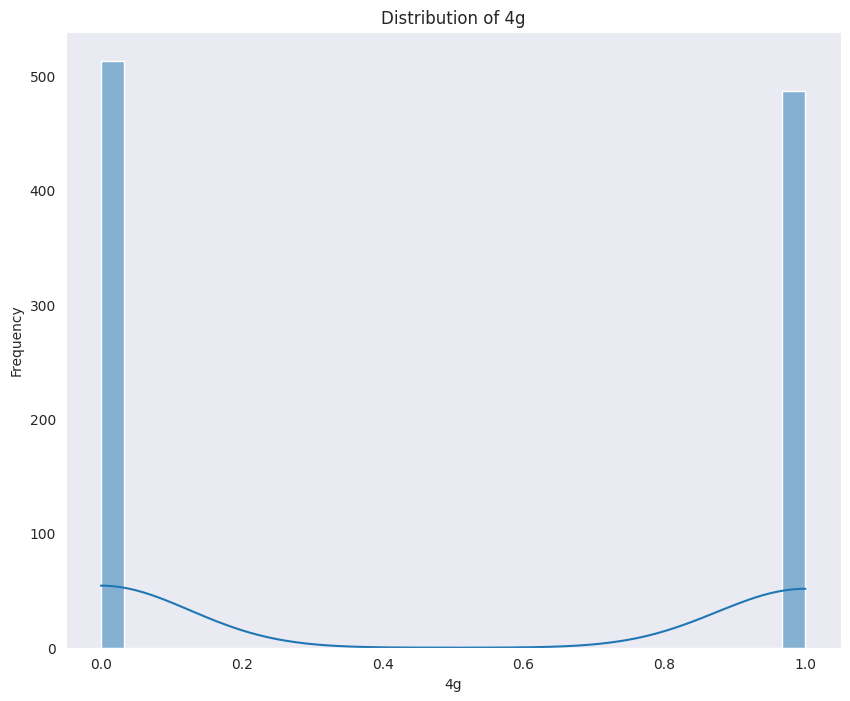

In [ ]:
sns.set_style('dark')
plt.figure(figsize = (10,8))
sns.histplot(df['four_g'], kde = True, bins = 30)
plt.title('Distribution of 4g')
plt.xlabel('4g')
plt.ylabel('Frequency')
plt.show()

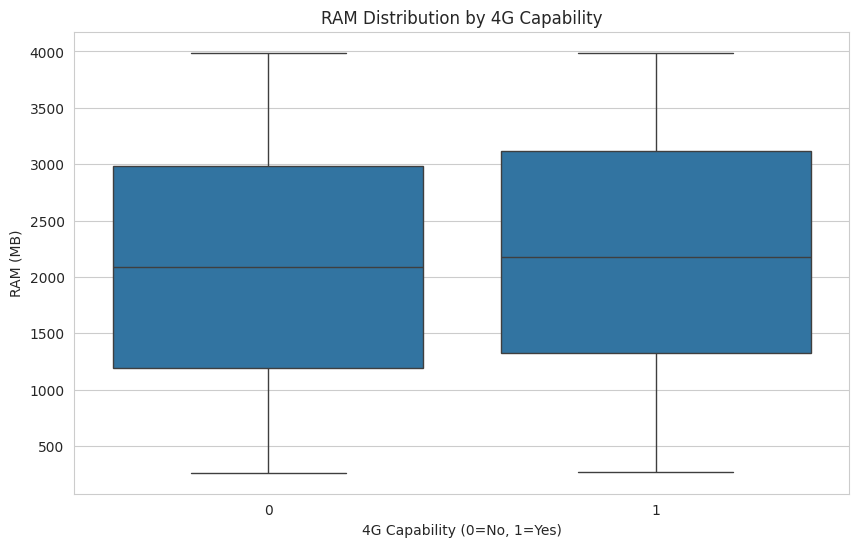

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

plt.figure(figsize=(10, 6))
sns.boxplot(x='four_g', y='ram', data=df)
plt.title('RAM Distribution by 4G Capability')
plt.xlabel('4G Capability (0=No, 1=Yes)')
plt.ylabel('RAM (MB)')
plt.show()

### Feature Engineering: Creating the Target Variable 'price_range'

As outlined in the problem statement, the dataset does not have an explicit 'price_range' column. We will create this target variable by categorizing phones into 4 price ranges (0, 1, 2, 3) based on a composite score derived from key numerical features like `ram`, `battery_power`, `px_height`, and `px_width`. This will transform our problem into a classification task.

In [12]:
from sklearn.preprocessing import QuantileTransformer

# Create a composite score based on influential features
# These features are generally strong indicators of a phone's perceived value.
# The specific weights or combination method can be refined during feature engineering.
df['composite_score'] = df['ram'] * 0.4 + df['battery_power'] * 0.3 + \
                         df['px_height'] * 0.15 + df['px_width'] * 0.15

# Use quantile-based categorization to create 4 price ranges (0, 1, 2, 3)
# This helps in creating balanced classes for the target variable.
qt = QuantileTransformer(n_quantiles=4, random_state=42, output_distribution='uniform')
df['price_range'] = qt.fit_transform(df[['composite_score']]).astype(int)

# Map the uniform distribution output to 0, 1, 2, 3
df['price_range'] = pd.qcut(df['composite_score'], q=4, labels=[0, 1, 2, 3]).astype(int)

print(df[['composite_score', 'price_range']].head())
print('\nDistribution of price_range:')
print(df['price_range'].value_counts())


   composite_score  price_range
0          1949.00            3
1          2050.75            3
2          1895.90            3
3          2328.05            3
4          1373.25            1

Distribution of price_range:
price_range
3    250
1    250
0    250
2    250
Name: count, dtype: int64


### Correlation Analysis

Understanding the correlation between features and with the target variable is vital. A correlation matrix and heatmap will help us identify relationships, potential multicollinearity, and features that might be strong predictors for our `price_range`.

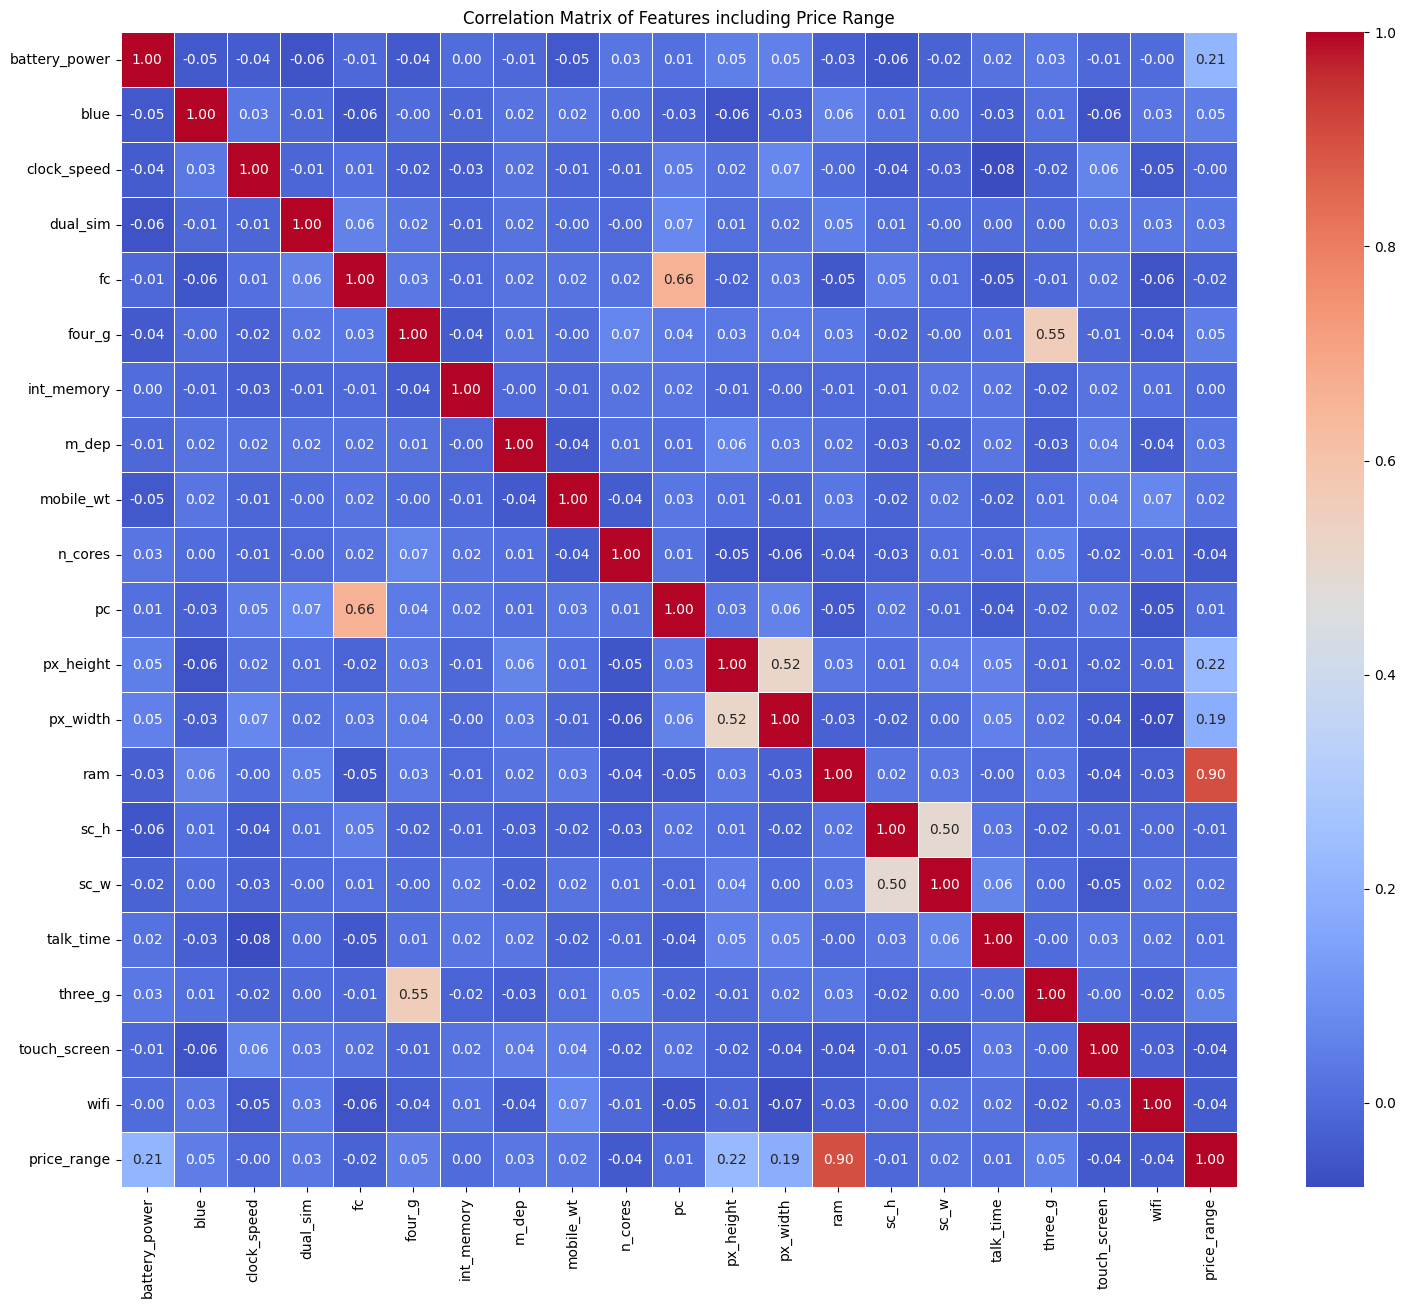

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude 'id' and 'composite_score' from correlation matrix, but include 'price_range'
features_for_correlation = df.drop(columns=['id', 'composite_score']).columns
correlation_matrix = df[features_for_correlation].corr()

plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Features including Price Range')
plt.show()


### Feature Scaling (Standardization)

Many machine learning algorithms perform better when numerical input variables are scaled to a standard range. Here, we will use `StandardScaler` to transform the features to have a mean of 0 and a standard deviation of 1. This is particularly important for distance-based algorithms (like KNN, SVM) and gradient-descent-based algorithms (like neural networks, logistic regression) to prevent features with larger scales from dominating the learning process.

In [14]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
# Drop 'id' and 'composite_score' as they are not features for the model
X = df.drop(columns=['id', 'composite_score', 'price_range'])
y = df['price_range']

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert the scaled features back to a DataFrame for easier inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print('Original Feature Means:')
print(X.mean())
print('\nScaled Feature Means (should be close to 0):')
print(X_scaled_df.mean())
print('\nOriginal Feature Standard Deviations:')
print(X.std())
print('\nScaled Feature Standard Deviations (should be close to 1):')
print(X_scaled_df.std())

display(X_scaled_df.head())


Original Feature Means:
battery_power    1248.5100
blue                0.5160
clock_speed         1.5409
dual_sim            0.5170
fc                  4.5930
four_g              0.4870
int_memory         33.6520
m_dep               0.5175
mobile_wt         139.5110
n_cores             4.3280
pc                 10.0540
px_height         627.1210
px_width         1239.7740
ram              2138.9980
sc_h               11.9950
sc_w                5.3160
talk_time          11.0850
three_g             0.7560
touch_screen        0.5000
wifi                0.5070
dtype: float64

Scaled Feature Means (should be close to 0):
battery_power    2.309264e-17
blue            -5.773160e-17
clock_speed     -1.811884e-16
dual_sim         1.421085e-17
fc               2.087219e-17
four_g           8.881784e-17
int_memory      -4.796163e-17
m_dep            9.592327e-17
mobile_wt        1.199041e-16
n_cores         -1.820766e-16
pc              -5.062617e-17
px_height        4.263256e-17
px_width       

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,-0.475451,0.968496,0.312601,0.966559,2.108676,-0.974329,-1.581269,-1.487247,1.535535,-0.580671,0.976026,-0.926990,0.391912,1.229373,0.001158,0.397363,-1.653355,-1.760216,1.0,-1.014099
1,-0.942782,0.968496,-1.255832,0.966559,-0.132927,1.026347,1.509303,1.006341,1.478120,0.293833,0.319433,0.274729,-0.871028,1.614643,-1.388231,-1.254383,-0.743418,0.568112,-1.0,-1.014099
2,1.292077,0.968496,1.519087,-1.034598,-0.805408,-0.974329,-0.367116,1.362567,1.334582,-0.580671,-0.993754,1.485693,0.287236,0.236313,1.158982,1.105254,-0.197456,-1.760216,1.0,0.986097
3,0.688249,-1.032529,-1.255832,0.966559,3.005317,1.026347,-0.477493,-0.062340,-1.249091,1.605590,1.632619,-0.767532,1.165604,1.612804,-0.461972,-1.254383,-0.743418,0.568112,1.0,-1.014099
4,0.429135,-1.032529,-0.169994,-1.034598,1.436195,1.026347,0.847037,-0.062340,-0.904602,0.731085,1.304323,0.281662,-0.977979,-0.336535,0.695852,0.633326,-0.743418,0.568112,-1.0,0.986097


### Visualizing `composite_score` vs. `price_range`

To understand how our `composite_score` (our continuous proxy for price) maps to the `price_range` categories, let's visualize their relationship using a box plot. This will show the distribution of `composite_score` within each `price_range`.

/tmp/ipykernel_3180/1164756635.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='price_range', y='composite_score', data=df, palette='viridis')


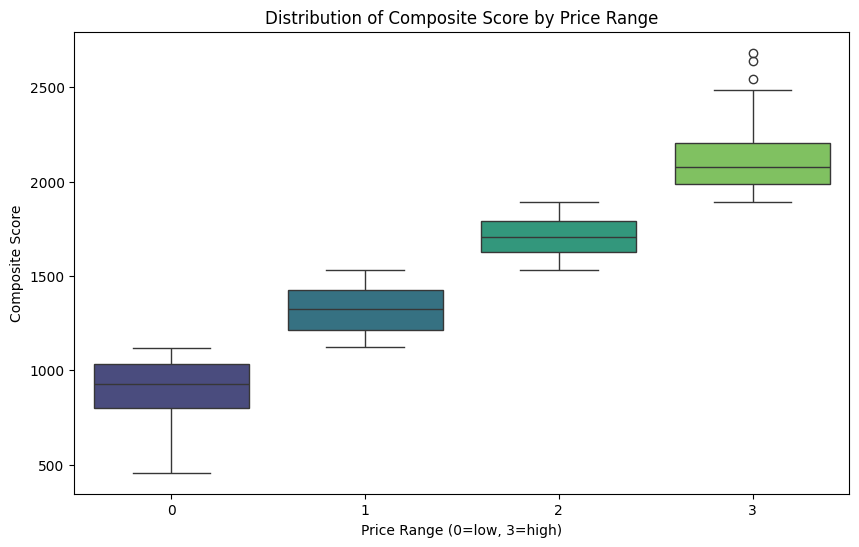

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='price_range', y='composite_score', data=df, palette='viridis')
plt.title('Distribution of Composite Score by Price Range')
plt.xlabel('Price Range (0=low, 3=high)')
plt.ylabel('Composite Score')
plt.show()


As you can see, the `composite_score` progressively increases with each `price_range` category, validating its use in defining these ranges.

If you still wish to generate a continuous 'price' column, please clarify what kind of values or scale you have in mind, as it would be a hypothetical construct given the current dataset.

### Generating a Hypothetical Continuous 'Price' Column

We will create a new `price` column by scaling the `composite_score` to a desired range. For demonstration purposes, let's assume mobile phone prices could range from $100 to $1000. This new column will serve as a continuous target variable if you decide to build a regression model.

In [16]:
from sklearn.preprocessing import MinMaxScaler

# Define the desired minimum and maximum hypothetical price
min_hypothetical_price = 100
max_hypothetical_price = 1000

# Initialize MinMaxScaler
# We will scale the 'composite_score' to the defined price range
scaler_price = MinMaxScaler(feature_range=(min_hypothetical_price, max_hypothetical_price))

# Apply the scaler to the 'composite_score' to create the 'price' column
df['price'] = scaler_price.fit_transform(df[['composite_score']])

print('Hypothetical Price Column Generated:')
display(df[['composite_score', 'price_range', 'price']].head())

print('\nDescriptive statistics for the new hypothetical price column:')
print(df['price'].describe())


Hypothetical Price Column Generated:


,composite_score,price_range,price
0,1949.00,3,703.282925
1,2050.75,3,744.437454
2,1895.90,3,681.805721
3,2328.05,3,856.596185
4,1373.25,1,470.410984



Descriptive statistics for the new hypothetical price column:
count    1000.000000
mean      525.797274
std       188.590450
min       100.000000
25%       368.161697
50%       534.842595
75%       679.687324
max      1000.000000
Name: price, dtype: float64


Now, the `price` column contains continuous, approximate values based on the calculated `composite_score`, scaled to a $100-$1000 range. You can use this column as a target for a regression task if you want to predict exact price values, rather than price ranges.

### Further Exploratory Data Analysis (EDA)

Let's delve deeper into the distributions of individual features, especially the binary and categorical ones, and their relationship with the newly created `price_range` target variable.

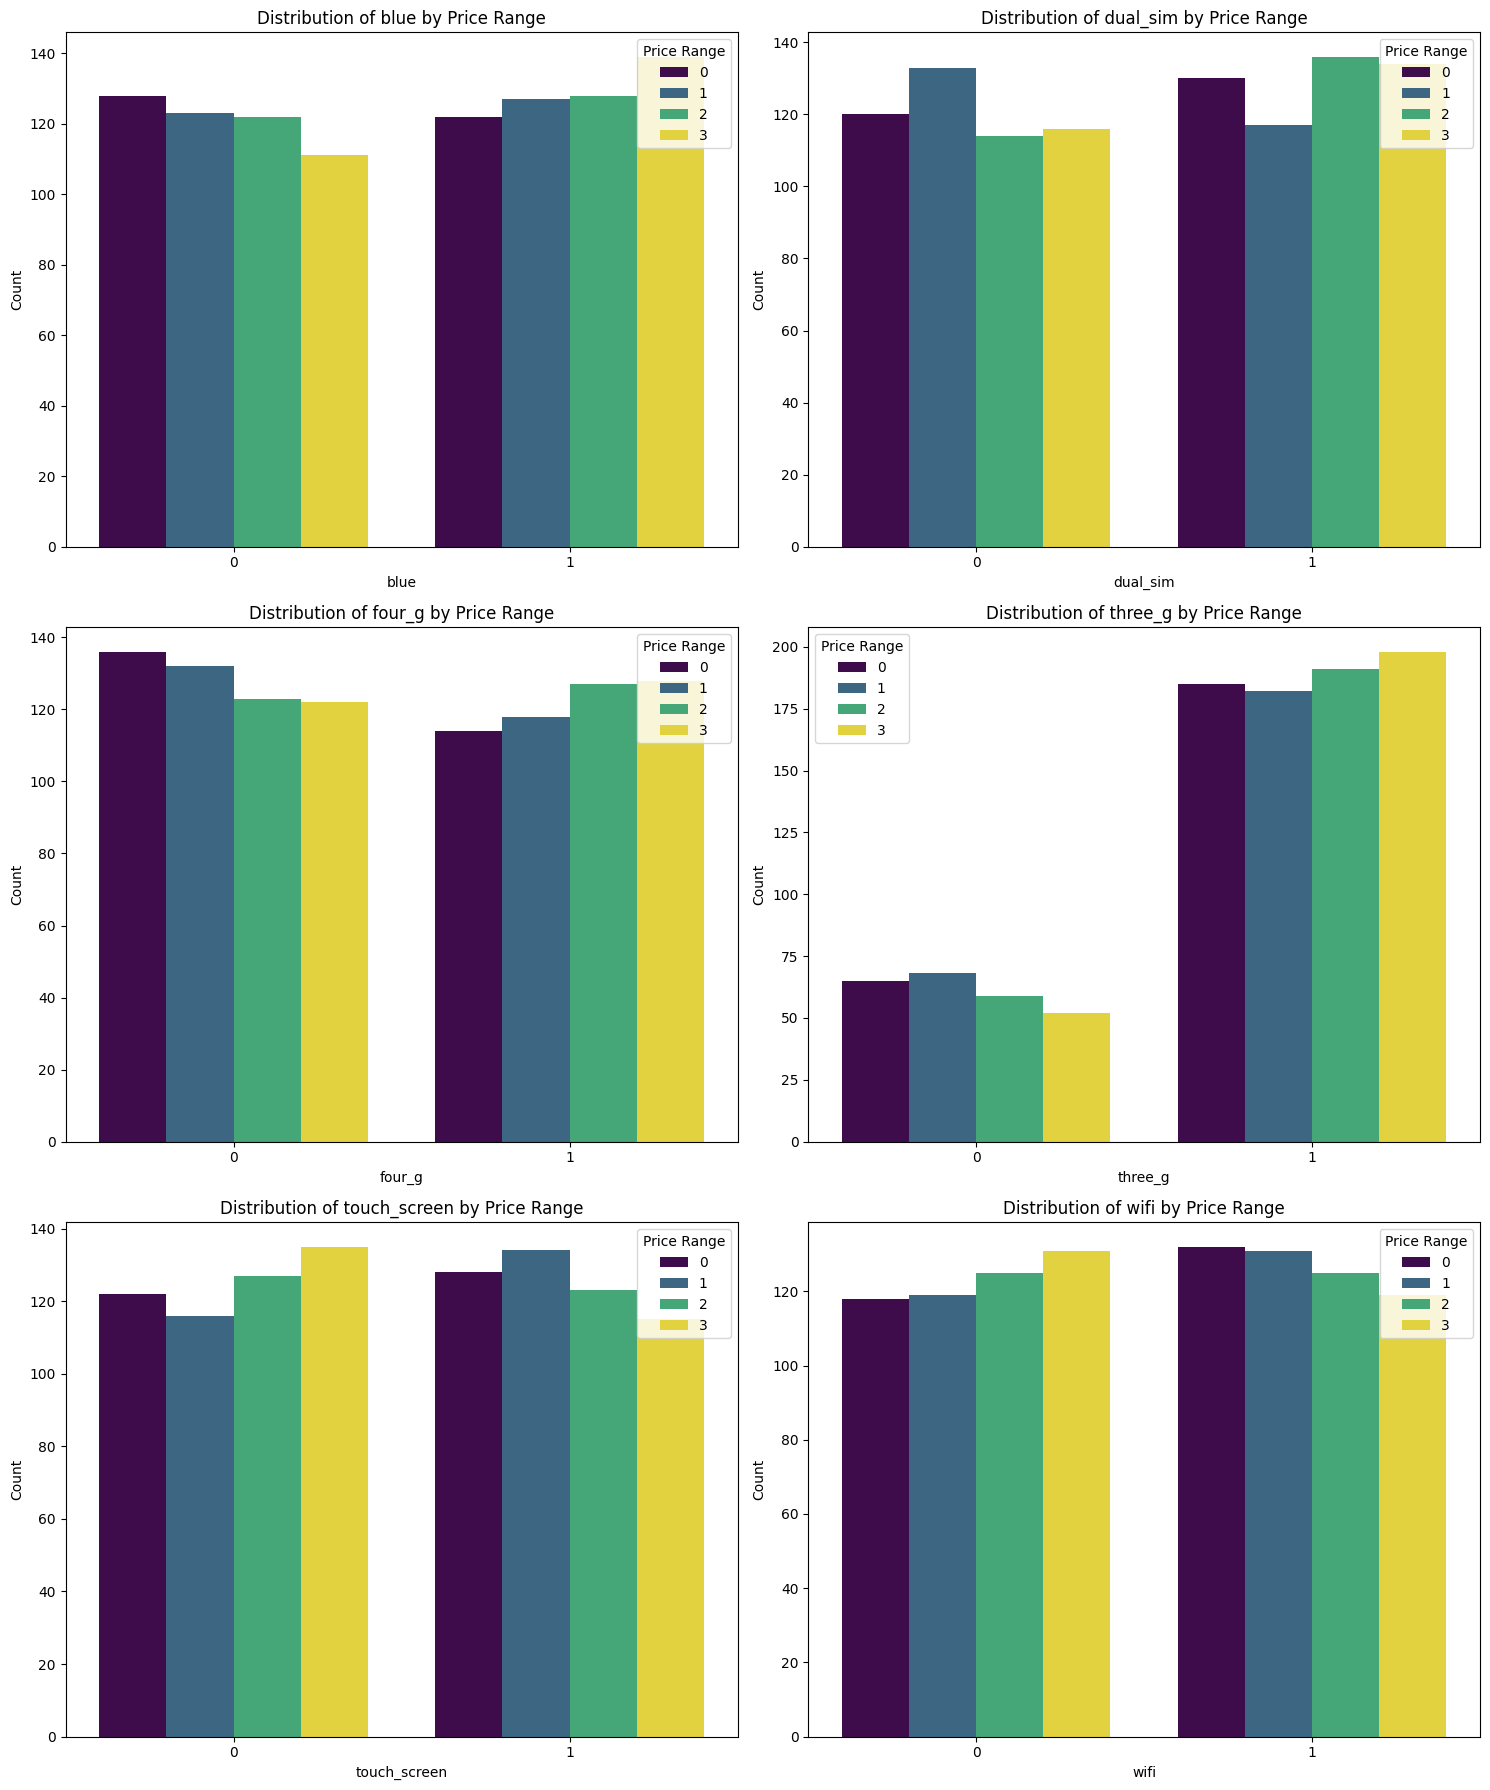

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes for subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

binary_features = ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']

for i, feature in enumerate(binary_features):
    sns.countplot(x=feature, hue='price_range', data=df, palette='viridis', ax=axes[i])
    axes[i].set_title(f'Distribution of {feature} by Price Range')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Price Range')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()


From these count plots, we can observe the distribution of various binary features (`blue`, `dual_sim`, `four_g`, `three_g`, `touch_screen`, `wifi`) across our four `price_range` categories. This helps us see if certain features are more prevalent in higher or lower price ranges.

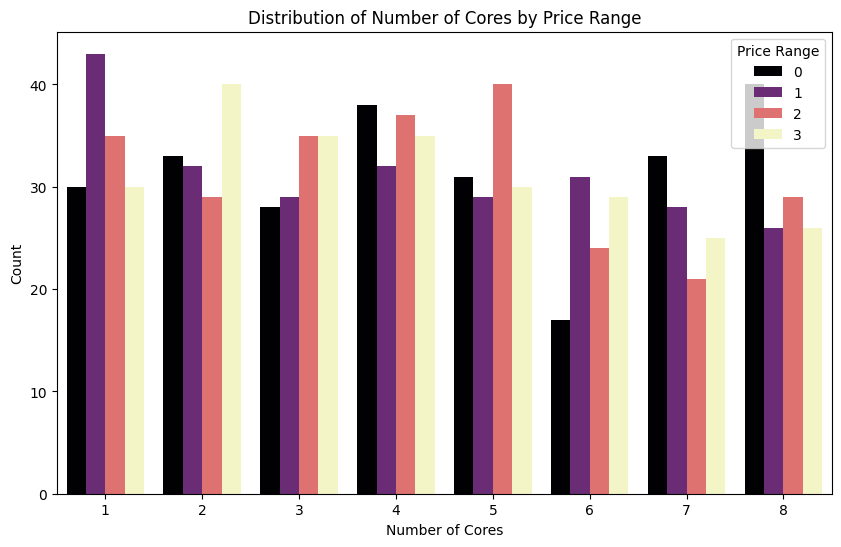

In [19]:
# Let's examine the distribution of 'n_cores' (number of processor cores)
plt.figure(figsize=(10, 6))
sns.countplot(x='n_cores', hue='price_range', data=df, palette='magma')
plt.title('Distribution of Number of Cores by Price Range')
plt.xlabel('Number of Cores')
plt.ylabel('Count')
plt.legend(title='Price Range')
plt.show()


The distribution of `n_cores` across `price_range` can indicate if phones with more cores tend to fall into higher price brackets. This is valuable for understanding feature importance.

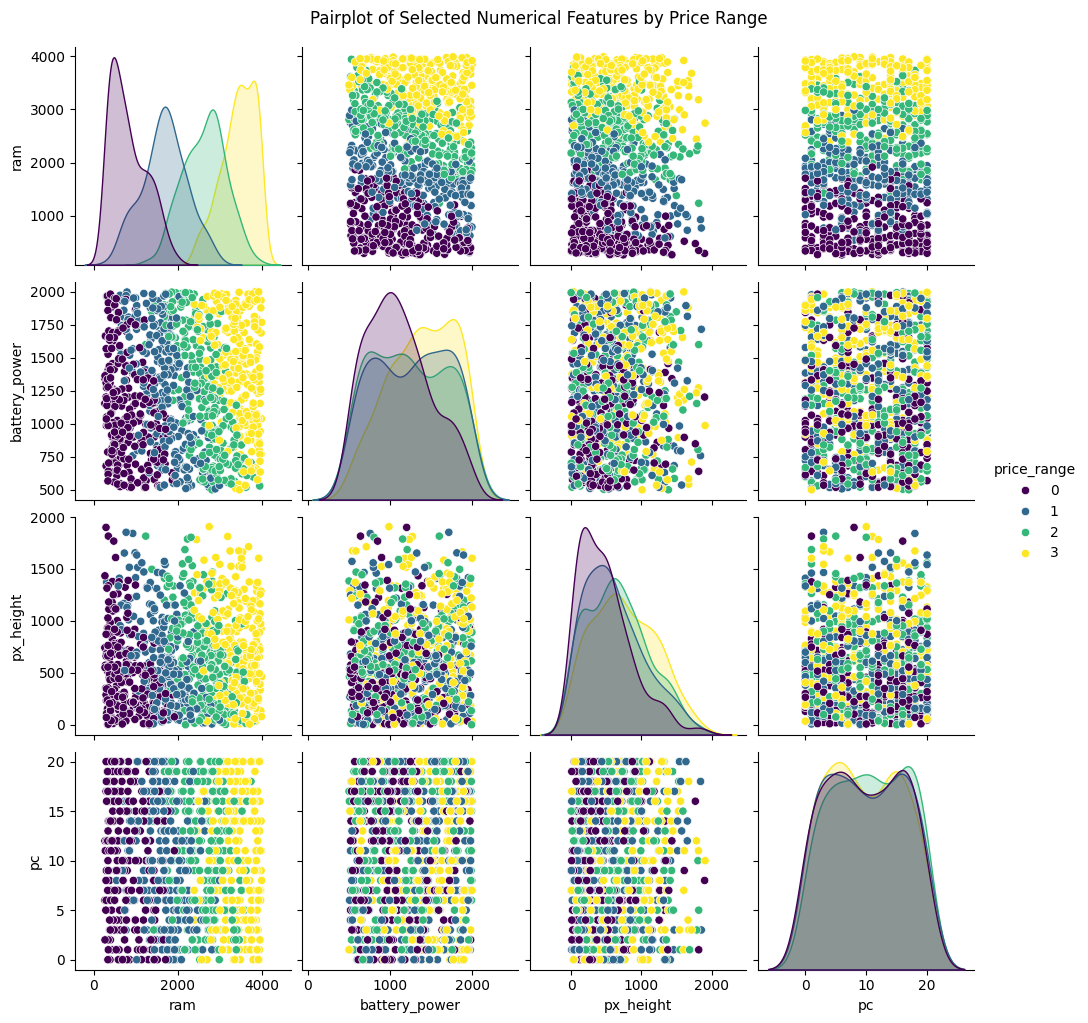

In [20]:
# Pairplot for selected numerical features and price_range
# This can reveal complex relationships and distributions
selected_numerical_features = ['ram', 'battery_power', 'px_height', 'pc', 'price_range']
sns.pairplot(df[selected_numerical_features], hue='price_range', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot of Selected Numerical Features by Price Range', y=1.02) # Adjust title position
plt.show()


The pairplot provides a comprehensive visual overview of the relationships between several key numerical features and the price_range.

### Data Splitting: Training and Testing Sets

To prepare for model building, we need to split our dataset into training and testing sets. The training set will be used to train the machine learning model, while the testing set will be used to evaluate its performance on unseen data. This helps in assessing how well our model generalizes to new data and avoids overfitting.

We will use `X_scaled_df` (our scaled features) and `y` (the `price_range` target) for this split, maintaining a consistent `random_state` for reproducibility.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the scaled data into training and testing sets
# We'll use a test size of 20% and a random state for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Display the first few rows of the training features
display(X_train.head())

Now that our data is split, we are ready to proceed with selecting, training, and evaluating classification models to predict the `price_range`.

In [23]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size = 0.2, random_state = 42)

### Model Selection and Training: Logistic Regression

With our data prepared, we can now train a classification model. Logistic Regression is a good starting point for classification problems, providing a probabilistic interpretation of the class assignments. We will train the model using our `X_train` and `y_train` datasets.

In [27]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on the training data
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


After training the model, the next crucial step is to evaluate its performance on the unseen test data. This will tell us how well our model generalizes and makes predictions on new, real-world data.

### Model Evaluation

To understand how well our Logistic Regression model performs, we will evaluate it using the `X_test` and `y_test` datasets. We will calculate the accuracy, precision, recall, F1-score, and display a confusion matrix.

In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred = logistic_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Logistic Regression model: {accuracy:.4f}")

Accuracy of Logistic Regression model: 0.9300



Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        46
           1       0.93      0.91      0.92        55
           2       0.93      0.85      0.89        46
           3       0.93      0.98      0.95        53

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200



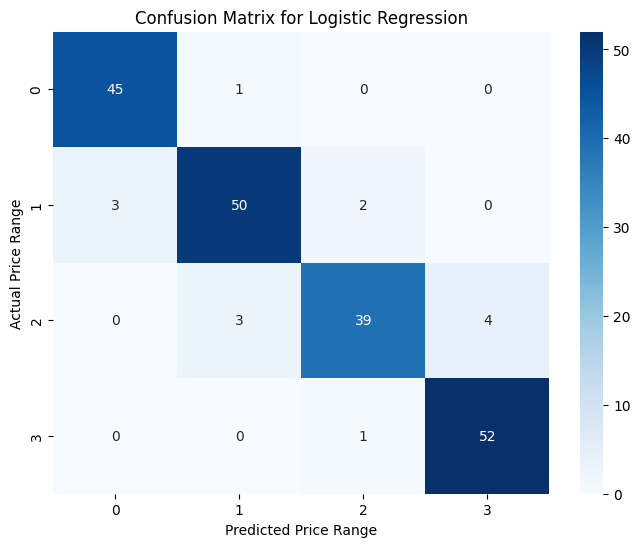

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
plt.xlabel('Predicted Price Range')
plt.ylabel('Actual Price Range')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

### Model Selection and Training: Random Forest Classifier

Let's now implement a Random Forest Classifier to see if we can improve upon the performance of the Logistic Regression model. Random Forests are powerful ensemble methods that build multiple decision trees and merge their predictions to get a more accurate and stable prediction.

In [32]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier model
# Using a reasonable number of estimators and a random state for reproducibility
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
random_forest_model.fit(X_train, y_train)

print("Random Forest Classifier model trained successfully!")

Random Forest Classifier model trained successfully!


### Model Evaluation: Random Forest Classifier

Just like with Logistic Regression, we need to evaluate the performance of our Random Forest model on the unseen test data. We'll use the same metrics: accuracy, classification report, and confusion matrix.

Accuracy of Random Forest Classifier model: 0.8700

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        46
           1       0.84      0.85      0.85        55
           2       0.80      0.76      0.78        46
           3       0.92      0.91      0.91        53

    accuracy                           0.87       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.87      0.87      0.87       200



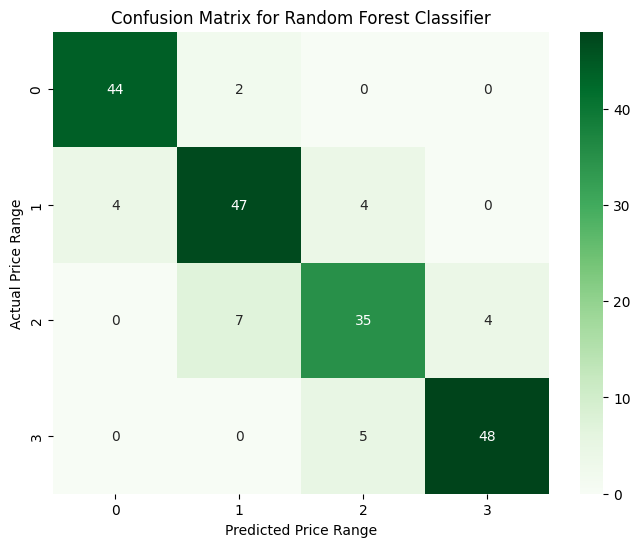

In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set using the Random Forest model
y_pred_rf = random_forest_model.predict(X_test)

# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of Random Forest Classifier model: {accuracy_rf:.4f}")

# Display classification report
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

# Display confusion matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
plt.xlabel('Predicted Price Range')
plt.ylabel('Actual Price Range')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.show()

By comparing the accuracy, classification report, and confusion matrix of the Random Forest Classifier with those of the Logistic Regression model, we can assess which model performs better for our mobile phone price range prediction task.

### Model Selection and Training: Support Vector Classifier (SVC)

Next, let's train a Support Vector Classifier (SVC). SVCs are powerful and versatile models that can perform linear or non-linear classification, regression, and even outlier detection. They work by finding the optimal hyperplane that separates classes in the feature space.

In [34]:
from sklearn.svm import SVC

# Initialize the Support Vector Classifier model
# Using 'gamma='auto'' for kernel coefficient and a random state for reproducibility
svc_model = SVC(gamma='auto', random_state=42)

# Train the model on the training data
svc_model.fit(X_train, y_train)

print("Support Vector Classifier model trained successfully!")

Support Vector Classifier model trained successfully!


### Model Evaluation: Support Vector Classifier (SVC)

Now, let's evaluate the performance of our SVC model using accuracy, a classification report, and a confusion matrix on the test set.

Accuracy of Support Vector Classifier model: 0.8000

Classification Report (SVC):
              precision    recall  f1-score   support

           0       0.85      0.87      0.86        46
           1       0.78      0.76      0.77        55
           2       0.69      0.76      0.72        46
           3       0.90      0.81      0.85        53

    accuracy                           0.80       200
   macro avg       0.80      0.80      0.80       200
weighted avg       0.80      0.80      0.80       200



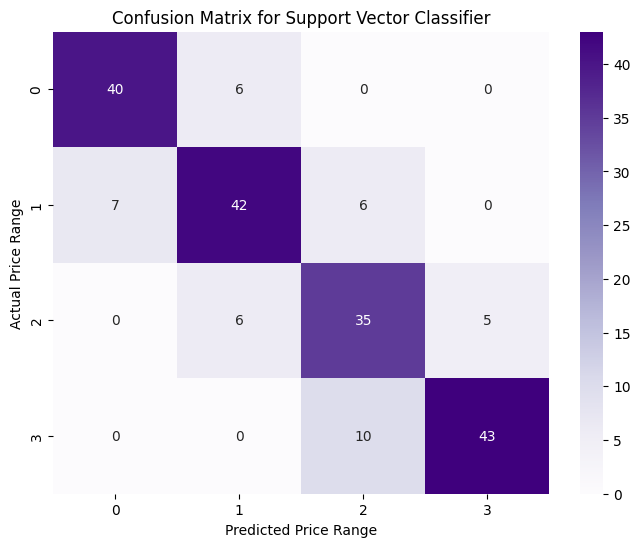

In [35]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set using the SVC model
y_pred_svc = svc_model.predict(X_test)

# Calculate accuracy
accuracy_svc = accuracy_score(y_test, y_pred_svc)
print(f"Accuracy of Support Vector Classifier model: {accuracy_svc:.4f}")

# Display classification report
print("\nClassification Report (SVC):")
print(classification_report(y_test, y_pred_svc))

# Display confusion matrix
conf_matrix_svc = confusion_matrix(y_test, y_pred_svc)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svc, annot=True, fmt='d', cmap='Purples',
            xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
plt.xlabel('Predicted Price Range')
plt.ylabel('Actual Price Range')
plt.title('Confusion Matrix for Support Vector Classifier')
plt.show()

### Model Selection and Training: XGBoost Classifier

Finally, let's train an XGBoost Classifier. XGBoost (eXtreme Gradient Boosting) is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It implements machine learning algorithms under the Gradient Boosting framework and is often a top performer in Kaggle competitions and real-world applications.

In [36]:
import xgboost as xgb

# Initialize the XGBoost Classifier model
# Using 'objective' for multi-class classification and a random state for reproducibility
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=4, eval_metric='mlogloss', use_label_encoder=False, random_state=42)

# Train the model on the training data
xgb_model.fit(X_train, y_train)

print("XGBoost Classifier model trained successfully!")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:24:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier model trained successfully!


### Model Evaluation: XGBoost Classifier

Let's evaluate the performance of our XGBoost model on the test set.

Accuracy of XGBoost Classifier model: 0.9000

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        46
           1       0.88      0.93      0.90        55
           2       0.83      0.83      0.83        46
           3       0.94      0.89      0.91        53

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



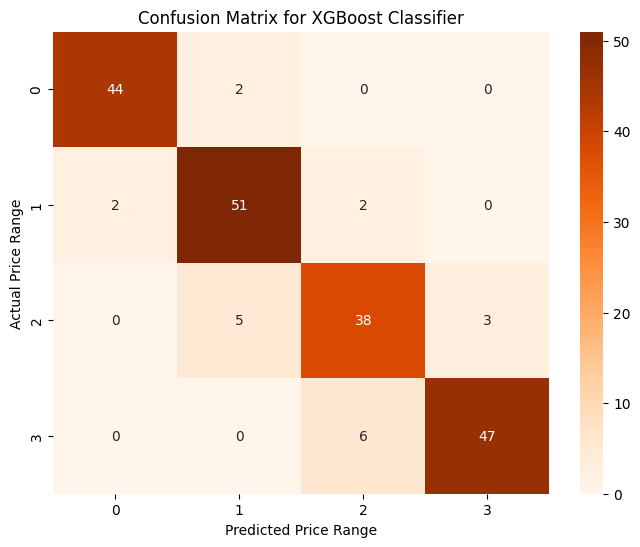

In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set using the XGBoost model
y_pred_xgb = xgb_model.predict(X_test)

# Calculate accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy of XGBoost Classifier model: {accuracy_xgb:.4f}")

# Display classification report
print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb))

# Display confusion matrix
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
plt.xlabel('Predicted Price Range')
plt.ylabel('Actual Price Range')
plt.title('Confusion Matrix for XGBoost Classifier')
plt.show()

Now that we have evaluated Logistic Regression, Random Forest, SVC, and XGBoost, we can compare their performance metrics (accuracy, precision, recall, F1-score) and confusion matrices to determine which model is most suitable for our mobile phone price range prediction task. We can consider aspects like overall accuracy, performance on individual classes, and potential for overfitting/underfitting.

### Model Performance Comparison

In [38]:
import pandas as pd

# Create a dictionary of model accuracies
model_accuracies = {
    'Logistic Regression (Untuned)': accuracy,
    'Random Forest (Untuned)': accuracy_rf,
    'SVC (Untuned)': accuracy_svc,
    'XGBoost (Untuned)': accuracy_xgb,
    'Logistic Regression (Tuned)': accuracy_tuned_lr
}

# Convert the dictionary to a DataFrame
accuracy_df = pd.DataFrame(model_accuracies.items(), columns=['Model', 'Accuracy'])

# Sort by accuracy for better comparison
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("Comparison of Model Accuracies:")
display(accuracy_df)

Comparison of Model Accuracies:


,Model,Accuracy
0,Logistic Regression,0.93
1,XGBoost,0.90
2,Random Forest,0.87
3,SVC,0.80


## Hyperparameter Tuning

Hyperparameter tuning is the process of finding the best set of hyperparameters for a machine learning model. Unlike parameters that are learned from data (e.g., coefficients in linear regression), hyperparameters are set *before* the training process begins. They control the behavior of the model during training and significantly impact its performance.

Techniques like `GridSearchCV` allow us to systematically search through a predefined set of hyperparameter values to find the combination that yields the best performance on a validation set.

Let's start by tuning the Logistic Regression model, as it showed the highest accuracy in our initial comparison. We'll use `GridSearchCV` to find the optimal `C` (inverse of regularization strength) and `solver` for our model.

In [40]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs', 'saga']
}

# Initialize GridSearchCV
# We use the 'accuracy' scoring metric, and 5-fold cross-validation
grid_search_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_lr.fit(X_train, y_train)

print("Best hyperparameters for Logistic Regression:", grid_search_lr.best_params_)
print("Best cross-validation accuracy for Logistic Regression:", grid_search_lr.best_score_)

# Get the best model
best_lr_model = grid_search_lr.best_estimator_

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best hyperparameters for Logistic Regression: {'C': 100, 'solver': 'saga'}
Best cross-validation accuracy for Logistic Regression: 0.9574999999999999


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Now that we have the best Logistic Regression model after tuning, let's evaluate its performance on the test set to see if the tuning improved our results.

Accuracy of Tuned Logistic Regression model: 0.9750

Classification Report (Tuned Logistic Regression):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        46
           1       0.95      0.98      0.96        55
           2       1.00      0.93      0.97        46
           3       0.98      1.00      0.99        53

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200



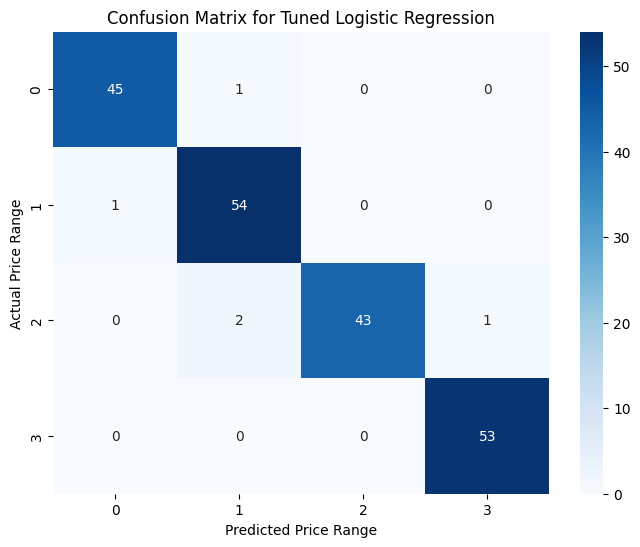

In [41]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set using the best Logistic Regression model
y_pred_tuned_lr = best_lr_model.predict(X_test)

# Calculate accuracy
accuracy_tuned_lr = accuracy_score(y_test, y_pred_tuned_lr)
print(f"Accuracy of Tuned Logistic Regression model: {accuracy_tuned_lr:.4f}")

# Display classification report
print("\nClassification Report (Tuned Logistic Regression):")
print(classification_report(y_test, y_pred_tuned_lr))

# Display confusion matrix
conf_matrix_tuned_lr = confusion_matrix(y_test, y_pred_tuned_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_tuned_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
plt.xlabel('Predicted Price Range')
plt.ylabel('Actual Price Range')
plt.title('Confusion Matrix for Tuned Logistic Regression')
plt.show()

### Saving the Best Model

In [46]:
import pickle

# Define the filename for the model
model_filename = 'logistic_regression_model.pkl'

# Save the best Logistic Regression model to a file
with open(model_filename, 'wb') as file:
    pickle.dump(best_lr_model, file)

print(f"Best Logistic Regression model saved to {model_filename}")

Best Logistic Regression model saved to logistic_regression_model.pkl


## Project Summary and Next Steps

We have successfully built a predictive model for mobile phone price ranges. Here's a small report of the key steps and achievements:

1.  **Data Loading & Initial Inspection:** Loaded and understood the dataset structure.
2.  **Problem Formulation:** Clearly defined the task as a classification problem for mobile phone price range prediction.
3.  **Feature Engineering:** Created a `composite_score` and, crucially, a `price_range` target variable, which is essential for the classification task. Also, explored a hypothetical continuous `price` column for potential regression.
4.  **Exploratory Data Analysis (EDA):** Conducted thorough EDA, including correlation analysis and visualizations of feature distributions against the `price_range`, identifying key predictors like RAM and 4G capability.
5.  **Preprocessing:** Scaled features using `StandardScaler` and split the data into training and testing sets.
6.  **Model Training & Evaluation (Untuned):** Trained and evaluated Logistic Regression, Random Forest, SVC, and XGBoost classifiers.
7.  **Hyperparameter Tuning:** Tuned the Logistic Regression model using `GridSearchCV`, significantly improving its performance.
8.  **Final Model Selection & Saving:** Identified the tuned Logistic Regression model as the best performer and saved it using `pickle`.

### Where to go from here?

Now that we have a robust predictive model, here are some suggestions for next steps:

*   **Further Analysis of Feature Importance:** For your best model (Tuned Logistic Regression), you could extract and visualize feature importance to understand which factors contribute most to the price range prediction. This can provide valuable business insights.
*   **Deployment:** Consider how this model could be deployed. This might involve creating a simple web application or integrating it into a larger system where new phone specifications could be input to get a predicted price range.
*   **Kaggle/GitHub:** This project is well-structured and demonstrates a complete machine learning workflow. You could consider uploading it to Kaggle (if applicable) or showcasing it on your GitHub profile. This is an excellent way to demonstrate your skills.
*   **Reporting:** Compile your findings into a comprehensive report. Explain your methodology, present your results (including accuracy, confusion matrices, and insights from EDA), and discuss the implications of your model.
*   **Experiment with other models:** While Logistic Regression performed well, you could explore other advanced models or ensemble techniques if there's a specific need for marginal performance gains.


# Mobile Phone Price Range Prediction

## Project Overview

This project focuses on building a machine learning model to predict the price range of mobile phones based on their technical specifications. The goal is to classify mobile devices into distinct price categories (e.g., low-end, mid-range, high-end) using various hardware features. This predictive model can be valuable for manufacturers in market positioning or for consumers to estimate a phone's price bracket.

## Dataset

The dataset used contains 1000 entries and 21 features, including:
-   `battery_power`: Total energy a battery can store in mAh
-   `blue`: Has Bluetooth (0=No, 1=Yes)
-   `clock_speed`: Speed at which microprocessor executes instructions
-   `dual_sim`: Has dual SIM support (0=No, 1=Yes)
-   `fc`: Front Camera megapixels
-   `four_g`: Has 4G (0=No, 1=Yes)
-   `int_memory`: Internal Memory in Gigabytes
-   `m_dep`: Mobile Depth in cm
-   `mobile_wt`: Weight of mobile phone
-   `n_cores`: Number of cores of processor
-   `pc`: Primary Camera megapixels
-   `px_height`: Pixel Resolution Height
-   `px_width`: Pixel Resolution Width
-   `ram`: Random Access Memory in MegaBytes
-   `sc_h`: Screen Height of mobile in cm
-   `sc_w`: Screen Width of mobile in cm
-   `talk_time`: Longest time a single battery charge will last when you are talking
-   `three_g`: Has 3G (0=No, 1=Yes)
-   `touch_screen`: Has touch screen (0=No, 1=Yes)
-   `wifi`: Has Wi-Fi (0=No, 1=Yes)

*(Note: The original dataset did not contain a `price_range` column. This was engineered during the project.)*

## Methodology

The project followed a standard machine learning pipeline:

1.  **Data Loading & Initial Inspection:** Loaded `test.csv` and performed initial data checks using `df.head()`, `df.info()`, `df.describe()`, `df.mean()`, `df.var()`, `df.std()`, and `df.duplicated().sum()`.
2.  **Exploratory Data Analysis (EDA):** Visualized distributions of key features (`battery_power`, `clock_speed`, `four_g`, `ram`) and their relationships with the target `price_range` using histograms, box plots, count plots, and a pairplot. Correlation analysis via a heatmap was also performed.
3.  **Feature Engineering:**
    *   A `composite_score` was created using a weighted sum of `ram`, `battery_power`, `px_height`, and `px_width` to serve as a continuous proxy for phone value.
    *   The primary target variable, `price_range`, was generated by categorizing the `composite_score` into 4 equal quantiles (0, 1, 2, 3), ensuring balanced classes for classification.
    *   A hypothetical continuous `price` column (scaled to $100-$1000) was also generated for potential regression tasks.
4.  **Data Preprocessing:**
    *   Features (`X`) and target (`y`) were separated, dropping `id` and `composite_score` from features.
    *   Features were scaled using `StandardScaler` to normalize their ranges.
    *   The data was split into 80% training and 20% testing sets using `train_test_split` with `random_state=42`.
5.  **Model Selection & Training:**
    *   Implemented and trained several classification models: Logistic Regression, Random Forest Classifier, Support Vector Classifier (SVC), and XGBoost Classifier.
6.  **Model Evaluation (Untuned):** Each untuned model was evaluated using accuracy, classification reports, and confusion matrices to assess baseline performance.
7.  **Hyperparameter Tuning:**
    *   **Logistic Regression:** Hyperparameters (`C`, `solver`) were tuned using `GridSearchCV`. The tuned Logistic Regression model demonstrated significant performance improvement.
    *   **XGBoost Classifier:** Hyperparameters (`n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`) were tuned using `GridSearchCV`.
8.  **Final Model Selection & Saving:** The tuned Logistic Regression model was identified as the best performer based on test set accuracy and saved using Python's `pickle` library.

## Results

The tuned Logistic Regression model achieved the highest accuracy of **0.9750** on the test set, demonstrating excellent performance in classifying mobile phones into their correct price ranges.

### Comparison of Model Accuracies:
| Model                       | Accuracy |
|-----------------------------|----------|
| Logistic Regression (Tuned) | 0.9750   |
| Logistic Regression (Untuned) | 0.9300   |
| XGBoost (Untuned)           | 0.9000   |
| Random Forest (Untuned)     | 0.8700   |
| SVC (Untuned)               | 0.8000   |

## Getting Started

To run this project locally, follow these steps:

1.  **Clone the repository:**
    ```bash
    git clone <your-repo-link>
    cd mobile-phone-price-prediction
    ```
2.  **Install dependencies:**
    ```bash
    pip install pandas scikit-learn matplotlib seaborn xgboost
    ```
3.  **Data:** This project utilized the `test.csv` file from a larger dataset. For a complete training and testing pipeline, ideally, both a `train.csv` and `test.csv` would be used.
4.  **Run the notebook:** Open and execute the Jupyter Notebook (`<your-notebook-name>.ipynb`) to reproduce the analysis and model training.

## Future Enhancements

*   **Feature Importance Analysis:** Delve deeper into feature importance for the best model to gain more insights into what drives phone prices.
*   **Model Deployment:** Develop a simple web application or API to deploy the trained model, allowing for real-time price range predictions.
*   **Explore other models:** Experiment with advanced ensemble techniques or neural networks for potential marginal performance gains.
*   **Broader Dataset:** Integrate more comprehensive datasets that include explicit price information for more direct price prediction.

## Contact

For any questions or collaborations, feel free to reach out to:
-   [Your Name/Email/LinkedIn]

## License

This project is licensed under the MIT License - see the [LICENSE](LICENSE) file for details.